In [ ]:
from google.colab import drive
drive.mount('/content/drive')


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
import os
os.listdir("/content/drive/MyDrive")

['Colab Notebooks',
 'Event-certificate-19324--1720546369.42484_copy.pdf',
 '2_copy.pdf',
 'Personalized_Marketing_AI_Design_Thinking.pdf',
 'IMG_20250522_133013.jpg',
 'Classroom',
 'IMG-20250930-WA0012.jpg',
 'NM MODULE 4 ASSESSMENT.png',
 'VID-20251014-WA0048.mp4',
 'VID-20251014-WA0049.mp4',
 'IMG-20251024-WA0014.jpg',
 'VID-20251029-WA0000.mp4',
 'VID-20251029-WA0001.mp4',
 'VID-20251105-WA0000.mp4',
 'VID-20251105-WA0001.mp4',
 'Sruthi Ranjani.pdf',
 'J.SRUTHI RANJANI.png',
 '2026-02-13_15-05-00.tiff',
 'Cam Ring.jpeg',
 'Cam Ring 2.jpeg',
 'Assignment 01 (18).pdf',
 'Assignment 01 (17).pdf',
 'Assignment 01 (16).pdf',
 'Assignment 01 (15).pdf',
 'Assignment 01 (14).pdf',
 'Assignment 01 (13).pdf',
 'Assignment 01 (12).pdf',
 'Assignment 01 (11).pdf',
 'Assignment 01 (10).pdf',
 'Assignment 01 (9).pdf',
 'Assignment 01 (8).pdf',
 'Assignment 01 (7).pdf',
 'Assignment 01 (6).pdf',
 'Assignment 01 (5).pdf',
 'Assignment 01 (4).pdf',
 'Assignment 01 (3).pdf',
 'Assignment 01 (2).pdf

In [ ]:
import cv2
image_path = "/content/drive/MyDrive/Cam Ring 2.jpeg"
img = cv2.imread(image_path)
print(img is None)

False


In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

output = img.copy()

gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
_, thresh = cv2.threshold(gray, 120, 255, cv2.THRESH_BINARY_INV)

kernel = np.ones((5,5), np.uint8)
thresh = cv2.morphologyEx(thresh, cv2.MORPH_CLOSE, kernel)

contours, _ = cv2.findContours(thresh, cv2.RETR_TREE, cv2.CHAIN_APPROX_SIMPLE)

valid_contours = []
for cnt in contours:
    if cv2.contourArea(cnt) > 5000:
        valid_contours.append(cnt)

print("Contours found:", len(valid_contours))


Contours found: 3


In [ ]:
for i,cnt in enumerate(valid_contours):
  print("Contour", i, "Area:",cv2.contourArea(cnt))

Contour 0 Area: 1167621.5
Contour 1 Area: 10674.5
Contour 2 Area: 172402.0


In [ ]:
from google.colab import files
uploaded = files.upload()

Saving Cam Ring 2.jpeg to Cam Ring 2.jpeg


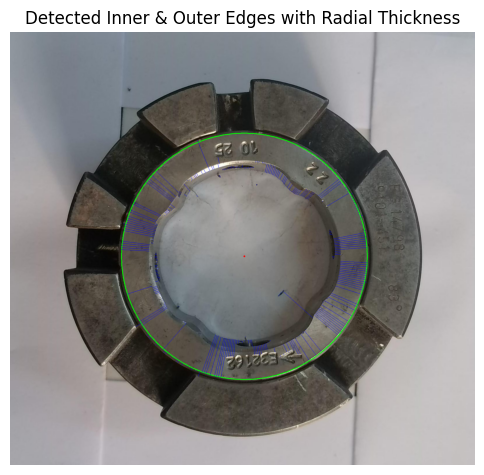

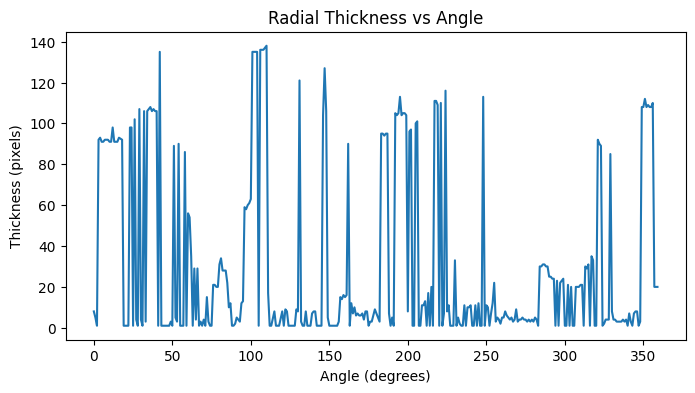

Process completed successfully.


In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

# -----------------------------
# 1. Load Image
# -----------------------------
image = cv2.imread("Cam Ring 2.jpeg")   # change filename if needed
output = image.copy()
gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)

# -----------------------------
# 2. Edge Detection
# -----------------------------
blur = cv2.GaussianBlur(gray, (5,5), 0)
edges = cv2.Canny(blur, 50, 150)

# -----------------------------
# 3. Detect Outer Circle (for center only)
# -----------------------------
circles = cv2.HoughCircles(
    blur,
    cv2.HOUGH_GRADIENT,
    dp=1.2,
    minDist=100,
    param1=100,
    param2=30,
    minRadius=50,
    maxRadius=0
)

if circles is None:
    print("Outer circle not detected")
    exit()

circles = np.uint16(np.around(circles))
x_center, y_center, outer_radius_est = circles[0][0]

# Draw detected outer circle (for reference)
cv2.circle(output, (x_center, y_center), outer_radius_est, (0,255,0), 2)
cv2.circle(output, (x_center, y_center), 3, (0,0,255), -1)

# -----------------------------
# 4. Radial Scanning
# -----------------------------
height, width = edges.shape
angles = []
thickness_values = []

for angle in range(0, 360):

    theta = np.deg2rad(angle)
    inner_r = None
    outer_r = None

    for r in range(1, outer_radius_est+50):

        x = int(x_center + r * np.cos(theta))
        y = int(y_center + r * np.sin(theta))

        if x < 0 or x >= width or y < 0 or y >= height:
            break

        if edges[y, x] == 255:

            if inner_r is None:
                inner_r = r
            else:
                outer_r = r
                break

    if inner_r is not None and outer_r is not None:
        thickness = outer_r - inner_r
        angles.append(angle)
        thickness_values.append(thickness)

        # Draw radial line (optional visual)
        x1 = int(x_center + inner_r * np.cos(theta))
        y1 = int(y_center + inner_r * np.sin(theta))
        x2 = int(x_center + outer_r * np.cos(theta))
        y2 = int(y_center + outer_r * np.sin(theta))
        cv2.line(output, (x1,y1), (x2,y2), (255,0,0), 1)

# -----------------------------
# 5. Save Dataset
# -----------------------------
data = pd.DataFrame({
    "Angle (deg)": angles,
    "Thickness (pixels)": thickness_values
})

data.to_csv("thickness_data.csv", index=False)

# -----------------------------
# 6. Show Results
# -----------------------------
plt.figure(figsize=(6,6))
plt.imshow(cv2.cvtColor(output, cv2.COLOR_BGR2RGB))
plt.title("Detected Inner & Outer Edges with Radial Thickness")
plt.axis("off")
plt.show()

# Plot thickness graph
plt.figure(figsize=(8,4))
plt.plot(angles, thickness_values)
plt.xlabel("Angle (degrees)")
plt.ylabel("Thickness (pixels)")
plt.title("Radial Thickness vs Angle")
plt.show()

print("Process completed successfully.")